# 1. Import necessary Libraries

In [40]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,recall_score,classification_report
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

In [16]:
wine_data=load_wine()
wine_data_df=pd.DataFrame(data=wine_data.data,columns=wine_data.feature_names)
wine_data_df["target"]=wine_data.target

In [17]:
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


## 3. Data understanding

In [19]:
wine_data_df.shape

(178, 14)

In [20]:
wine_data_df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [21]:
wine_data_df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

In [22]:
wine_data_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 4. Data Preparation/Preprocessing

In [23]:
# There is no null values or the object and hence there is no need to perform any imputation or the conversion from object to numeric datatype.
# Perform the Data Transformation since all the input feature are having different units and it has to convert it into the same 
# using since we are using the KNN algorith which need the units of the input feature should be same.

In [26]:
X=wine_data_df.drop(labels="target",axis=1)
y=wine_data_df["target"]

In [27]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [28]:
y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

In [29]:
std_scaler=StandardScaler()
scaled_X=std_scaler.fit_transform(X)
scaled_X

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

## 4. Model Building

In [33]:
X_train,X_test,y_train,y_test=train_test_split(scaled_X,y,test_size=0.20,shuffle=True,random_state=23,stratify=y)

In [35]:
knn_model=KNeighborsClassifier(n_neighbors=5)

## 5. Model Training

In [36]:
knn_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 6. Model Testing || 7. Model Evaluation

### Training data

In [37]:
y_pred_train=knn_model.predict(X_train)

In [38]:
# Evaluation
print("Accuracy Score:",accuracy_score(y_train,y_pred_train))

Accuracy Score: 0.971830985915493


### How to choose the Optimal no.of neighbours?
* Create a for loop to build the model with multiple n_neighors value which is a hyperparamer.

In [64]:
kfold=KFold(n_splits=5, shuffle=True, random_state=50)
cv_scores_mean=[]

for i in range(3,52,2):
    knn_model=KNeighborsClassifier(n_neighbors=i)
    knn_model.fit(X_train,y_train)
    
    # y_pred_train=knn_model.predict(X_train)
    cv_scores=cross_val_score(estimator=knn_model,X=X_train,y=y_train,cv=kfold)
    cv_scores_mean.append(cv_scores.mean().round(4))
    

In [65]:
cv_scores_mean

[np.float64(0.9367),
 np.float64(0.9574),
 np.float64(0.9645),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9788),
 np.float64(0.9719),
 np.float64(0.9788),
 np.float64(0.9719),
 np.float64(0.9645),
 np.float64(0.9574),
 np.float64(0.9643),
 np.float64(0.9574),
 np.float64(0.9576),
 np.float64(0.9576),
 np.float64(0.9576),
 np.float64(0.9576),
 np.float64(0.9645),
 np.float64(0.9645),
 np.float64(0.9645),
 np.float64(0.9507),
 np.float64(0.9579),
 np.float64(0.9648),
 np.float64(0.9645),
 np.float64(0.9505)]

In [66]:
max(cv_scores_mean)

np.float64(0.9788)

In [67]:
cv_scores_mean.index(max(cv_scores_mean))

5

## Let's visualize this

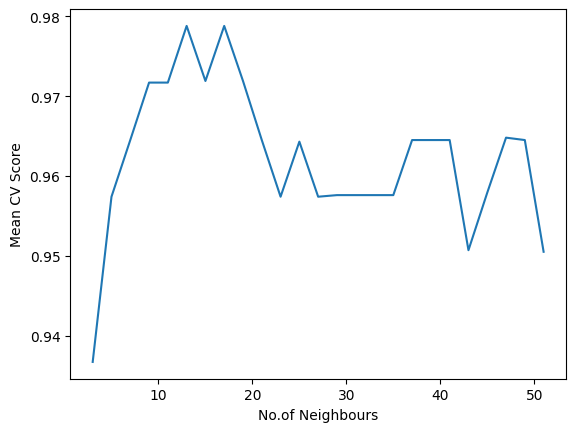

In [68]:
from matplotlib import pyplot as plt
plt.plot(range(3,52,2),cv_scores_mean)
plt.xlabel("No.of Neighbours")
plt.ylabel("Mean CV Score")
plt.show()

In [69]:
knn_model=KNeighborsClassifier(n_neighbors=13)
knn_model.fit(X_train,y_train)
y_pred_train=knn_model.predict(X_train)
# Evaluation
print("Accuracy Score:",round(accuracy_score(y_train,y_pred_train),4))


Accuracy Score: 0.9789


## The End!